# 0. Contexto del dataset.

#####Este dataset está generado con un modelo de deep learning (train.csv, 188533 filas) basándose en un dataset con información sobre automóviles (used_cars.csv, 4009 filas). Ambos se pueden obtener aquí: https://www.kaggle.com/competitions/playground-series-s4e9/data

#####Las columnas que contiene son las siguientes:
- Brand y Model: indica la marca y el modelo específico.
- Model_year: indica el año de fabricación del vehículo.
- Mileage: indica el kilometraje (en millas) de cada vehículo.
- Fuel_type: indica si el vehículo es de gasolina, diesel, eléctrico o híbrido.
- Engine_type: indica las especificaciones del motor.
- Transmission: indica el tipo de transmisión, si es automático, manual o de alguna variante.
- Ext_col e int_col: indica el color interior y exterior.
- Accident: indica si el vehículo tiene un historial de accidentes o daños.
- Clean_title: indica si el vehículo ha sido dañado o reconstruido.
- Price: indica el precio de cada vehículo.

# 1. Se importan las librerías esenciales.

In [103]:
# Instalación sileciosa (sin output) de missingno
%%capture
!pip install missingno

#Importamos librerías esenciales
import pandas as pd # Para manejo de datos
import numpy as np # Para operaciones numéricas
import plotly as pl # Para visualizaciones interactivas
import seaborn as sns # Para gráficos estadísticos
import matplotlib.pyplot as plt #Para visualizaciones
import missingno as msno # Para visualizar datos faltantes

# 2. Se carga el dataset.

In [104]:
df_train = pd.read_csv('train.csv')

In [105]:
#Nos aseguramos de que sea un dataframe
df_train = pd.DataFrame(df_train)

# 3. Limpieza.

## 3.1. Data overview.




In [106]:
df_train.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [107]:
df_train.tail()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
188528,188528,Cadillac,Escalade ESV Platinum,2017,49000,Gasoline,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Beige,None reported,Yes,27500
188529,188529,Mercedes-Benz,AMG C 43 AMG C 43 4MATIC,2018,28600,Gasoline,385.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,30000
188530,188530,Mercedes-Benz,AMG GLC 63 Base 4MATIC,2021,13650,Gasoline,469.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes,86900
188531,188531,Audi,S5 3.0T Prestige,2022,13895,Gasoline,3.0L,1-Speed Automatic,Daytona Gray Pearl Effect,Black,None reported,NaN,84900
188532,188532,Porsche,Macan Base,2016,59500,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,None reported,Yes,28995


In [108]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


##3.2. Duplicados y nulos.

In [109]:
#Para evitar errores o pérdida de información original se crea una copia:
df_train_copy = df_train.copy()

In [110]:
# Buscamos duplicados
df_train_copy.duplicated().sum()

np.int64(0)

No hay duplicados.

In [111]:
#Se cuentan nulos de cada columna.
missing = df_train_copy.isna().sum().sort_values(ascending=False)
print(missing)

clean_title     21419
fuel_type        5083
accident         2452
brand               0
id                  0
milage              0
model_year          0
model               0
engine              0
ext_col             0
transmission        0
int_col             0
price               0
dtype: int64


In [112]:
#Para ver el % de valores nulos en porcentaje de cada columna.
porcentaje_missing = (df_train_copy.isna().mean()*100).sort_values(ascending=False)
print(porcentaje_missing)

clean_title     11.360876
fuel_type        2.696080
accident         1.300568
brand            0.000000
id               0.000000
milage           0.000000
model_year       0.000000
model            0.000000
engine           0.000000
ext_col          0.000000
transmission     0.000000
int_col          0.000000
price            0.000000
dtype: float64


<Axes: >

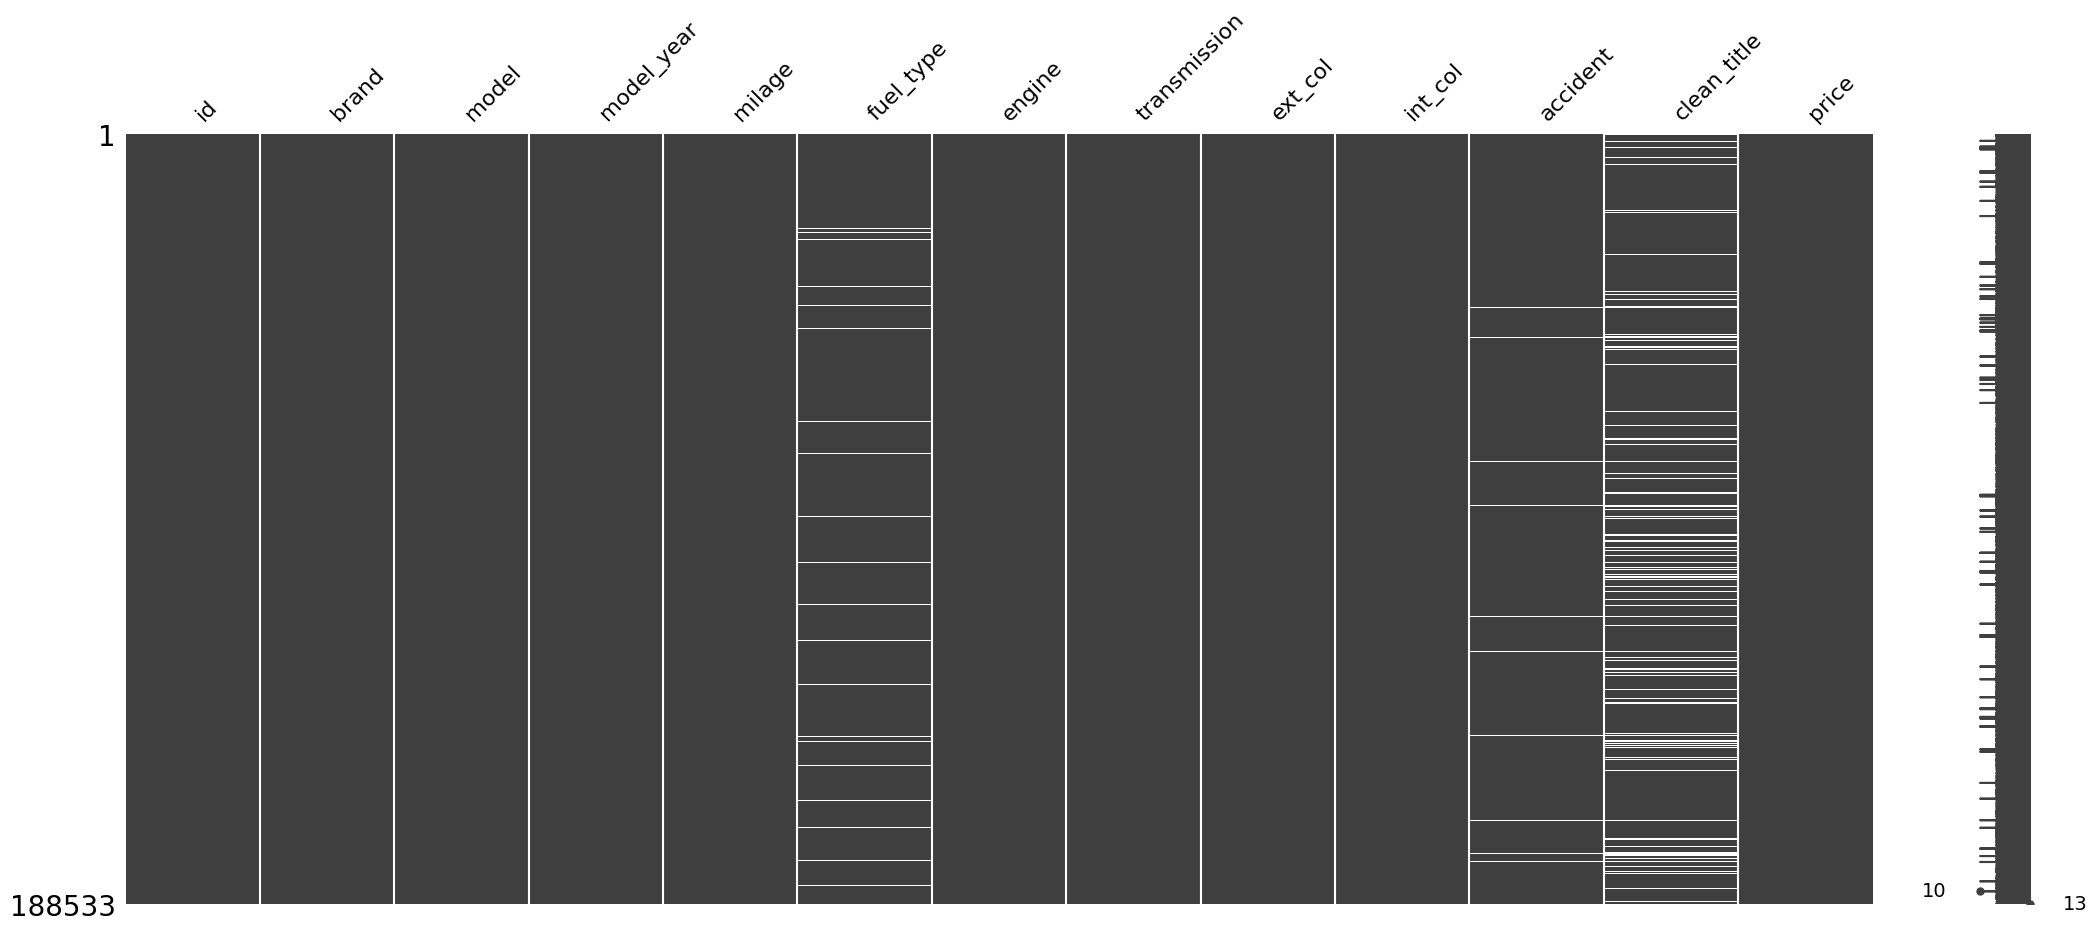

In [113]:
#Otras formas de ver los valores nulos.
msno.matrix(df_train_copy)

<Axes: >

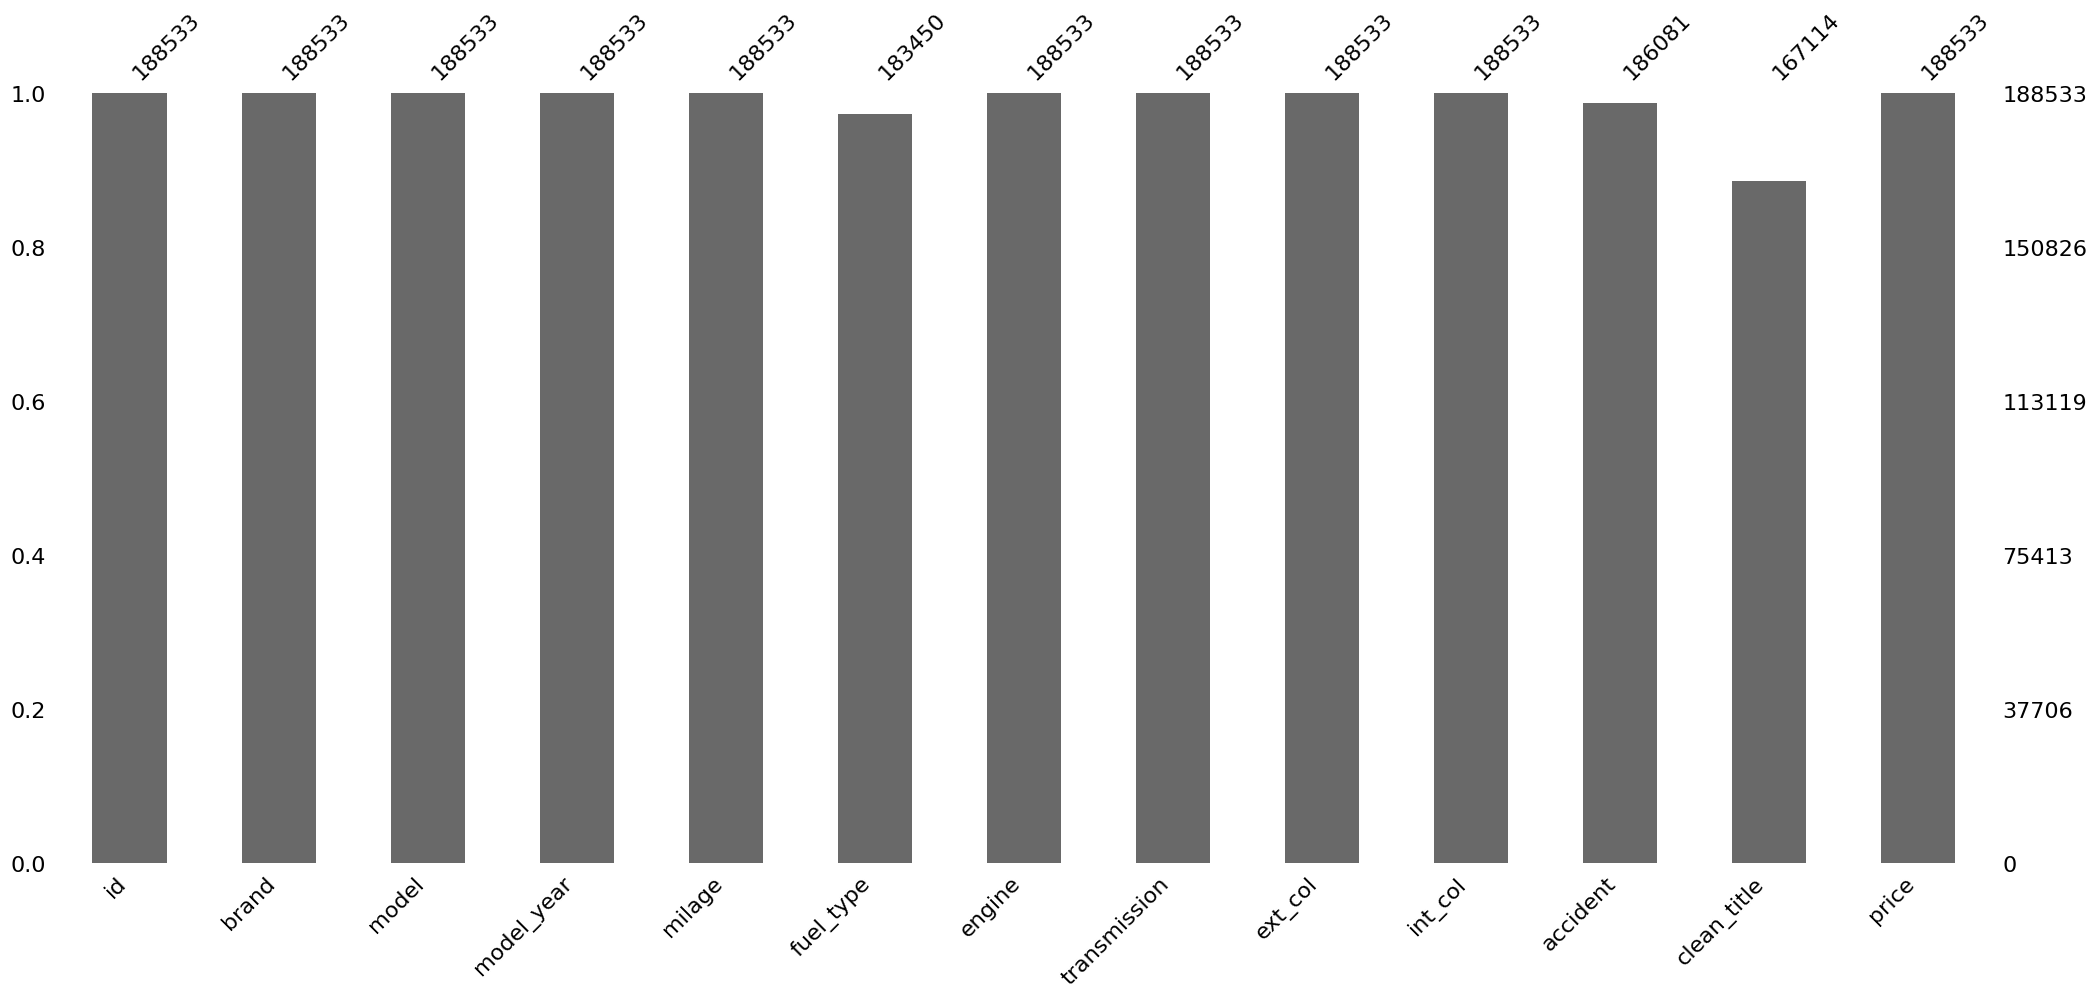

In [114]:
msno.bar(df_train_copy)

In [115]:
#Ahora miramos los valores únicos y los contamos
valores_accident = df_train_copy['accident'].value_counts()
nulos_accident = pd.Series([df_train_copy['accident'].isnull().sum()], index=['Valores nulos']) #Se crea una serie con pandas para poder añadirle el nombre de valores nulos
total_accident = pd.Series([df_train_copy['accident'].shape[0]], index=['Total']) #Shape[0] indica el total de las filas (shape(filas, columnas))


accident_conteo_nulos_total = pd.concat([valores_accident, nulos_accident ,total_accident])
display(accident_conteo_nulos_total)

,0
None reported,144514
At least 1 accident or damage reported,41567
Valores nulos,2452
Total,188533


Viendo estos datos, se decide que los nulos de la columna 'accident' no se van a eliminar, sino que se van a sustituir por 'None reported', ya que se considera  que pueden ocurrir accidentes y no reportarse.

In [116]:
df_train_copy['accident'] = df_train_copy['accident'].fillna('None reported')

In [117]:
#Ahora se mira la columna de 'clean_title':
valores_cleantitle = df_train_copy['clean_title'].value_counts()
nulos_cleantitle = pd.Series([df_train_copy['clean_title'].isnull().sum()], index=['Valores nulos']) #Se crea una serie con pandas para poder añadirle el nombre de valores nulos
total_cleantitle = pd.Series([df_train_copy['clean_title'].shape[0]], index=['Total']) #Shape[0] indica el total de las filas (shape(filas, columnas))


cleantitle_conteo_nulos_total = pd.concat([valores_cleantitle, nulos_cleantitle ,total_cleantitle])
display(cleantitle_conteo_nulos_total)

,0
Yes,167114
Valores nulos,21419
Total,188533


Viendo estos datos hemos decidido sustituir los nulos de clean_title, ya que al ser una columna que puede ser importante a la hora de decidirse comprarse un coche o no, la vamos a dejar sin borrar filas y ese grupo de valores nulos lo sustituiremos por 'Unknown' porque podríamos usarlo luego en el EDA y aportar información relevante.


In [118]:
df_train_copy['clean_title'] = df_train_copy['clean_title'].fillna('Unknown')

In [119]:
#Ahora la columna de 'fuel_type':
valores_fueltype = df_train_copy['fuel_type'].value_counts()
nulos_fueltype = pd.Series([df_train_copy['fuel_type'].isnull().sum()], index=['Valores nulos']) #Se crea una serie con pandas para poder añadirle el nombre de valores nulos
total_fueltype = pd.Series([df_train_copy['fuel_type'].shape[0]], index=['Total']) #Shape[0] indica el total de las filas (shape(filas, columnas))


fueltype_conteo_nulos_total = pd.concat([valores_fueltype, nulos_fueltype ,total_fueltype])
display(fueltype_conteo_nulos_total)

,0
Gasoline,165940
Hybrid,6832
E85 Flex Fuel,5406
Diesel,3955
–,781
Plug-In Hybrid,521
not supported,15
Valores nulos,5083
Total,188533


In [120]:
#Se miran las filas de los nulos de la columna de fuel_type
df_train_copy[df_train_copy['fuel_type'].isna()]

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
11,11,Tesla,Model S P100D,2015,81500,NaN,Electric Motor Electric Fuel System,1-Speed A/T,Gray,White,None reported,Yes,19000
32,32,Tesla,Model S P100D,2018,30300,NaN,518.0HP Electric Motor Electric Fuel System,A/T,White,White,None reported,Yes,64000
51,51,Tesla,Model 3 Long Range,2020,38360,NaN,Dual Motor - Standard,Automatic,White,Black,None reported,Unknown,59598
52,52,Tesla,Model X 75D,2021,88000,NaN,518.0HP Electric Motor Electric Fuel System,1-Speed A/T,Black,Black,None reported,Yes,53600
161,161,Tesla,Model S Long Range,2021,9500,NaN,670.0HP Electric Motor Electric Fuel System,A/T,White,Beige,None reported,Yes,89999
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188368,188368,Ford,Mustang Mach-E Premium,2022,2058,NaN,Standard Range Battery,Automatic CVT,Red,Black,None reported,Unknown,27785
188455,188455,Ford,Mustang Mach-E GT,2022,8000,NaN,480.0HP Electric Motor Electric Fuel System,A/T,Orange,White,None reported,Yes,115000
188462,188462,Ford,Mustang Mach-E GT,2023,9000,NaN,480.0HP Electric Motor Electric Fuel System,A/T,Orange,Black,None reported,Yes,85000
188484,188484,Ford,Model X P100D,2018,52000,NaN,534.0HP Electric Motor Electric Fuel System,1-Speed A/T,Gray,Black,None reported,Yes,45000


In [121]:
df_train_copy[df_train_copy['fuel_type'] == '–']

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
532,532,Dodge,Challenger R/T Scat Pack,2021,35000,–,–,8-Speed A/T,Blue,Gray,None reported,Yes,48000
1155,1155,Ford,Mustang GT Premium,2017,143600,–,–,6-Speed M/T,White,Black,At least 1 accident or damage reported,Yes,31000
1307,1307,Toyota,Land Cruiser Base,1994,138033,–,–,A/T,Green,Beige,None reported,Yes,11999
1362,1362,Ford,Mustang EcoBoost Premium,2016,43000,–,–,A/T,Blue,Black,None reported,Yes,15500
1741,1741,Chevrolet,Protege DX,1993,94200,–,–,A/T,Red,Gray,None reported,Yes,7599
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187399,187399,Mazda,MX-5 Miata Base,1993,90200,–,–,5-Speed M/T,Gray,Black,At least 1 accident or damage reported,Yes,11500
187495,187495,Nissan,Pathfinder SL,2014,87305,–,284.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Brown,Gray,At least 1 accident or damage reported,Yes,10000
187664,187664,Mercedes-Benz,SLS AMG Base,1993,14586,–,–,A/T,Red,Silver,None reported,Yes,65000
187820,187820,Chrysler,Pacifica Touring,2017,57300,–,–,9-Speed A/T,Blue,Black,None reported,Yes,31700


In [122]:
df_train_copy[df_train_copy['engine'] == '–']

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
532,532,Dodge,Challenger R/T Scat Pack,2021,35000,–,–,8-Speed A/T,Blue,Gray,None reported,Yes,48000
1155,1155,Ford,Mustang GT Premium,2017,143600,–,–,6-Speed M/T,White,Black,At least 1 accident or damage reported,Yes,31000
1307,1307,Toyota,Land Cruiser Base,1994,138033,–,–,A/T,Green,Beige,None reported,Yes,11999
1362,1362,Ford,Mustang EcoBoost Premium,2016,43000,–,–,A/T,Blue,Black,None reported,Yes,15500
1741,1741,Chevrolet,Protege DX,1993,94200,–,–,A/T,Red,Gray,None reported,Yes,7599
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187399,187399,Mazda,MX-5 Miata Base,1993,90200,–,–,5-Speed M/T,Gray,Black,At least 1 accident or damage reported,Yes,11500
187664,187664,Mercedes-Benz,SLS AMG Base,1993,14586,–,–,A/T,Red,Silver,None reported,Yes,65000
187820,187820,Chrysler,Pacifica Touring,2017,57300,–,–,9-Speed A/T,Blue,Black,None reported,Yes,31700
187964,187964,Mercedes-Benz,C-Class 4MATIC Sedan,1993,22703,Gasoline,–,A/T,Gray,–,None reported,Yes,220000


Los nulos de la columna 'fuel_type' corresponde todo con motores tipo eléctricos, por lo que los sustituiremos por 'Electric'.

También se observa que casi siempre coincide que hay '-' en las columnas de 'engine' y 'fuel_type'. Se sustituirán por 'Unknown', ya que no se sabe qué tipo de motor tienen y no queremos quitar esas filas. Podrían llegar a obtenerse esos valores uno a uno con el modelo y la marca.

In [123]:
df_train_copy['fuel_type'] = df_train_copy['fuel_type'].fillna('Electric')

df_train_copy['fuel_type'] = df_train_copy['fuel_type'].replace('-', 'Unknown')


df_train_copy['engine'] = df_train_copy['engine'].replace('-', 'Unknown')


In [124]:
#Se comprueban los cambios:
df_train_copy.head()


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [125]:
df_train_copy.tail()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
188528,188528,Cadillac,Escalade ESV Platinum,2017,49000,Gasoline,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Beige,None reported,Yes,27500
188529,188529,Mercedes-Benz,AMG C 43 AMG C 43 4MATIC,2018,28600,Gasoline,385.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,30000
188530,188530,Mercedes-Benz,AMG GLC 63 Base 4MATIC,2021,13650,Gasoline,469.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes,86900
188531,188531,Audi,S5 3.0T Prestige,2022,13895,Gasoline,3.0L,1-Speed Automatic,Daytona Gray Pearl Effect,Black,None reported,Unknown,84900
188532,188532,Porsche,Macan Base,2016,59500,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,None reported,Yes,28995


In [126]:
#Se comprueba que no hay valores nulos ya:
df_train_copy.isna().sum().sort_values(ascending=False)

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0


In [127]:
df_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     188533 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      188533 non-null  object
 11  clean_title   188533 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


##3.3. Tipado de columnas

Ahora, empezaremos con el tipado de cada columna.

Las columnas 'brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident' y 'clean_title' hay que cambiarlas de object a string.

In [128]:
#Se cambian las columnas de object a string:
df_train_copy['brand'] = df_train_copy['brand'].astype('string')
df_train_copy['model'] = df_train_copy['model'].astype('string')
df_train_copy['fuel_type'] = df_train_copy['fuel_type'].astype('string')
df_train_copy['engine'] = df_train_copy['engine'].astype('string')
df_train_copy['transmission'] = df_train_copy['transmission'].astype('string')
df_train_copy['ext_col'] = df_train_copy['ext_col'].astype('string')
df_train_copy['int_col'] = df_train_copy['int_col'].astype('string')
df_train_copy['accident'] = df_train_copy['accident'].astype('string')
df_train_copy['clean_title'] = df_train_copy['clean_title'].astype('string')

In [129]:
#Se comprueban los cambios.
df_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  string
 2   model         188533 non-null  string
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     188533 non-null  string
 6   engine        188533 non-null  string
 7   transmission  188533 non-null  string
 8   ext_col       188533 non-null  string
 9   int_col       188533 non-null  string
 10  accident      188533 non-null  string
 11  clean_title   188533 non-null  string
 12  price         188533 non-null  int64 
dtypes: int64(4), string(9)
memory usage: 18.7 MB


In [130]:
#Nos aseguramos que los datos de tipo 'string' no tengan espacios innecesarios y que estén escritas en minúsculas.
def clean_text(s):
  return s.astype(str).str.strip().str.lower()

for col in df_train_copy.columns:
  if df_train_copy[col].dtype == 'string':
    df_train_copy[col] = clean_text(df_train_copy[col])

In [131]:
#Se comrpueba:
df_train_copy.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,mini,cooper s base,2007,213000,gasoline,172.0hp 1.6l 4 cylinder engine gasoline fuel,a/t,yellow,gray,none reported,yes,4200
1,1,lincoln,ls v8,2002,143250,gasoline,252.0hp 3.9l 8 cylinder engine gasoline fuel,a/t,silver,beige,at least 1 accident or damage reported,yes,4999
2,2,chevrolet,silverado 2500 lt,2002,136731,e85 flex fuel,320.0hp 5.3l 8 cylinder engine flex fuel capab...,a/t,blue,gray,none reported,yes,13900
3,3,genesis,g90 5.0 ultimate,2017,19500,gasoline,420.0hp 5.0l 8 cylinder engine gasoline fuel,transmission w/dual shift mode,black,black,none reported,yes,45000
4,4,mercedes-benz,metris base,2021,7388,gasoline,208.0hp 2.0l 4 cylinder engine gasoline fuel,7-speed a/t,black,beige,none reported,yes,97500


## 3.4. Se miran los outliers por si hay que eliminarlos.

In [132]:
#Se hacen boxplots para ver si hay outliers
cols = ["price", "model_year", "milage"]

outliers_iqr = {}

for col in cols:
    Q1 = df_train_copy[col].quantile(0.25)
    Q3 = df_train_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_train_copy[(df_train_copy[col] < lower) | (df_train_copy[col] > upper)]
    outliers_iqr[col] = outliers

    print(f"\n Outliers en {col} (IQR): {len(outliers)} valores")
    print(outliers[[col]].head())


 Outliers en price (IQR): 10880 valores
     price
31  104900
36  165000
43  244896
44  145000
65  193063

 Outliers en model_year (IQR): 5132 valores
    model_year
1         2002
2         2002
59        2001
81        2000
88        2002

 Outliers en milage (IQR): 1766 valores
     milage
0    213000
10   212500
28   244200
195  269885
424  215000


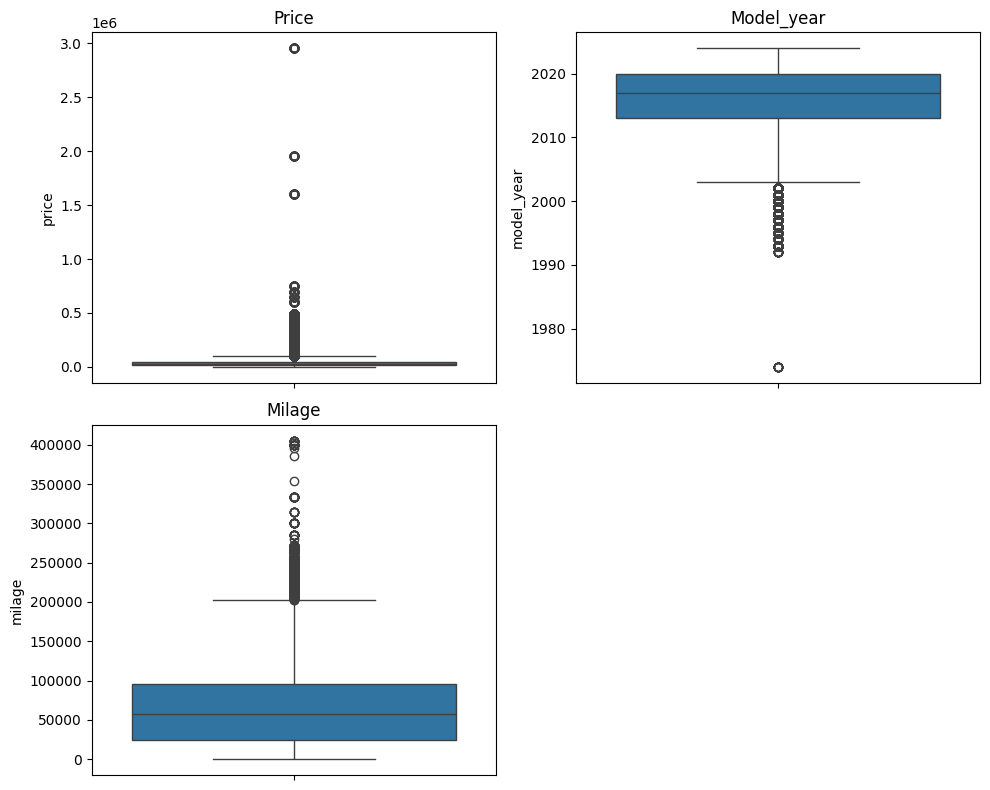

In [133]:
#Se hacen boxplots para encontrar valores anómalos.

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Boxplot de price (arriba izquierda)
sns.boxplot(y=df_train_copy["price"], ax=axes[0, 0])
axes[0, 0].set_title("Price")

# Boxplot de model_year (arriba derecha)
sns.boxplot(y=df_train_copy["model_year"], ax=axes[0, 1])
axes[0, 1].set_title("Model_year")

# Boxplot de milage (abajo izquierda)
sns.boxplot(y=df_train_copy["milage"], ax=axes[1, 0])
axes[1, 0].set_title("Milage")

# Ocupamos la última celda vacía con un espacio en blanco
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()





Hay unos pocos que destacan por el precio ya que son extremadamente caros, también ocurre con el kilometraje ya que hay algunos que tienen muchos, pero no es lo normal.

A medida que pasan los años, cada vez quedarán menos de años muy anteriores.

Por todo esto, se decide no quitar datos porque aunque sean outliers son significativos en este contexto.

## 3.5. Estadística descriptiva general básica.

In [134]:
df_train_copy.describe()

,id,model_year,milage,price
count,188533.000000,188533.000000,188533.000000,1.885330e+05
mean,94266.000000,2015.829998,65705.295174,4.387802e+04
std,54424.933488,5.660967,49798.158076,7.881952e+04
min,0.000000,1974.000000,100.000000,2.000000e+03
25%,47133.000000,2013.000000,24115.000000,1.700000e+04
50%,94266.000000,2017.000000,57785.000000,3.082500e+04
75%,141399.000000,2020.000000,95400.000000,4.990000e+04
max,188532.000000,2024.000000,405000.000000,2.954083e+06


Se observa que hay variaciones grandes en el precio, van desde 2000 a casi 3 millones de dólares.

También ocurre con el kilometraje que van desde 100 millas a más de 400 mil.

El rango de la edad de los coches van desde 1974 al 2024. En esta columna no tienen sentido las medidas de media, count o desviación típica.

##3.6. Se exporta el archivo ya limpio en formato csv.

In [135]:
#Se guarda el archivo y se exporta en formato csv.
from google.colab import files
df_train_copy.to_csv('limpiezaP7grupo2.csv', index=False)
#Se pondrá un archivo 'limpiezaP7.csv' directamente en la zona de Archivos.

#Para descargar automáticamente, quitar # de la siguiente línea
#files.download('limpiezaP7grupo2.csv')

#4. Análisis exploratorio de datos (EDA).

Se dividen las columnas de precio y milage en distintas categorías para poder ver mejor si hay outliers. Ya que al haber coches con muchos años y de distintas marcas, algunas de lujo, al hacerlo en general puede no apreciarse.

Las categorías escogidas han sido:
- precio: bajo, medio, alto, de lujo
- milage: bajo, medio, alto

Para model_year no haremos ni categorías ni quitaremos ningún dato ya que entendemos que a medida que pasan los años cada vez quedarán menos coches con más antigüedad, de ahí que salgan valores anómalos en esta columna.

In [136]:
p25 = df_train_copy['price'].quantile(0.25)
p50 = df_train_copy['price'].quantile(0.50)
p90 = df_train_copy['price'].quantile(0.90)

print('P25:', p25, 'P50:', p50, 'P90:', p90)

P25: 17000.0 P50: 30825.0 P90: 78500.0


In [137]:
#Categorías de precios

#El valor mínimo y máximo
min_val = df_train_copy['price'].min()
max_val = df_train_copy['price'].max()

#Se crean las categorías: bajo (min-p25), medio(p25-p50), alto(p50-p90), de lujo(p90-max)
bins_precio = [
    min_val, #mínimo real
    17200, #p25
    31000, #p50
    79999, #p90
    max_val #máximo real
]

labels_precio =['bajo','medio', 'alto','de lujo']

df_train_copy['price_group'] = pd.cut(df_train_copy['price'], bins=bins_precio, labels=labels_precio, right=False)

#Ver resumen
print(df_train_copy['price_group'].value_counts())
print('Min:', min_val, 'Max:', max_val)

price_group
alto       75528
bajo       47975
medio      46868
de lujo    18112
Name: count, dtype: int64
Min: 2000 Max: 2954083


In [138]:
#Para comprobar que se ha creado la nueva columna.
df_train_copy.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,price_group
0,0,mini,cooper s base,2007,213000,gasoline,172.0hp 1.6l 4 cylinder engine gasoline fuel,a/t,yellow,gray,none reported,yes,4200,bajo
1,1,lincoln,ls v8,2002,143250,gasoline,252.0hp 3.9l 8 cylinder engine gasoline fuel,a/t,silver,beige,at least 1 accident or damage reported,yes,4999,bajo
2,2,chevrolet,silverado 2500 lt,2002,136731,e85 flex fuel,320.0hp 5.3l 8 cylinder engine flex fuel capab...,a/t,blue,gray,none reported,yes,13900,bajo
3,3,genesis,g90 5.0 ultimate,2017,19500,gasoline,420.0hp 5.0l 8 cylinder engine gasoline fuel,transmission w/dual shift mode,black,black,none reported,yes,45000,alto
4,4,mercedes-benz,metris base,2021,7388,gasoline,208.0hp 2.0l 4 cylinder engine gasoline fuel,7-speed a/t,black,beige,none reported,yes,97500,de lujo


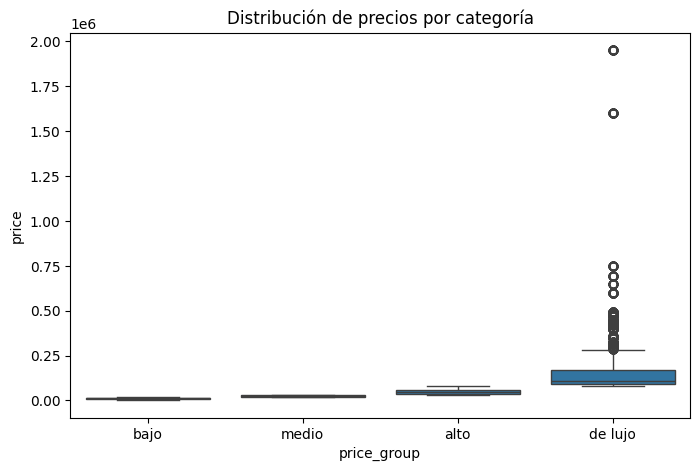

In [139]:
#Se hacen boxplots para las categorías de price.
plt.figure(figsize=(8,5))
sns.boxplot(data=df_train_copy, x='price_group', y='price')
plt.title('Distribución de precios por categoría')
plt.show()



In [140]:
#Se hace también para la columna 'milage':

#El valor mínimo y máximo
min_val = df_train_copy['milage'].min()
max_val = df_train_copy['milage'].max()

#Se crean las categorías: bajo (min-100000), medio(100001-200000), alto(>200001)
bins_milage = [
    min_val, #mínimo real
    100000,
    200000,
    max_val #máximo real
]

labels_milage =['bajo','medio', 'alto']

df_train_copy['milage_group'] = pd.cut(df_train_copy['milage'], bins=bins_milage, labels=labels_milage, right=False)

#Ver resumen
print(df_train_copy['milage_group'].value_counts())
print('Min:', min_val, 'Max:', max_val)

milage_group
bajo     145904
medio     40669
alto       1952
Name: count, dtype: int64
Min: 100 Max: 405000


In [141]:
#Para comprobarlo:
df_train_copy.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,price_group,milage_group
0,0,mini,cooper s base,2007,213000,gasoline,172.0hp 1.6l 4 cylinder engine gasoline fuel,a/t,yellow,gray,none reported,yes,4200,bajo,alto
1,1,lincoln,ls v8,2002,143250,gasoline,252.0hp 3.9l 8 cylinder engine gasoline fuel,a/t,silver,beige,at least 1 accident or damage reported,yes,4999,bajo,medio
2,2,chevrolet,silverado 2500 lt,2002,136731,e85 flex fuel,320.0hp 5.3l 8 cylinder engine flex fuel capab...,a/t,blue,gray,none reported,yes,13900,bajo,medio
3,3,genesis,g90 5.0 ultimate,2017,19500,gasoline,420.0hp 5.0l 8 cylinder engine gasoline fuel,transmission w/dual shift mode,black,black,none reported,yes,45000,alto,bajo
4,4,mercedes-benz,metris base,2021,7388,gasoline,208.0hp 2.0l 4 cylinder engine gasoline fuel,7-speed a/t,black,beige,none reported,yes,97500,de lujo,bajo


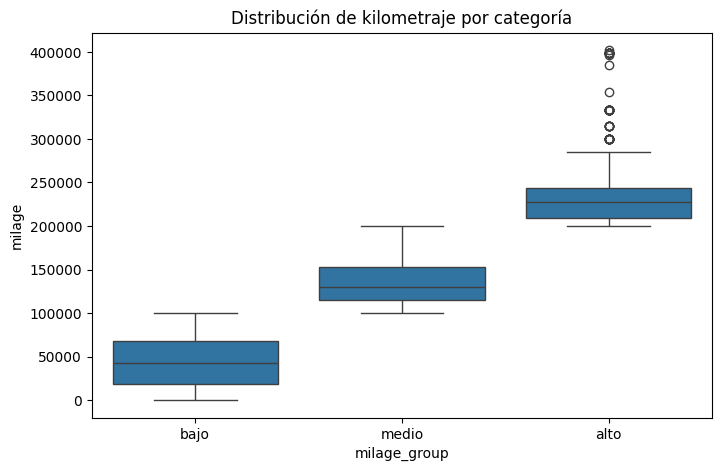

In [142]:
#Se hacen boxplots para las categorías de milage.
plt.figure(figsize=(8,5))
sns.boxplot(data=df_train_copy, x='milage_group', y='milage')
plt.title('Distribución de kilometraje por categoría')
plt.show()

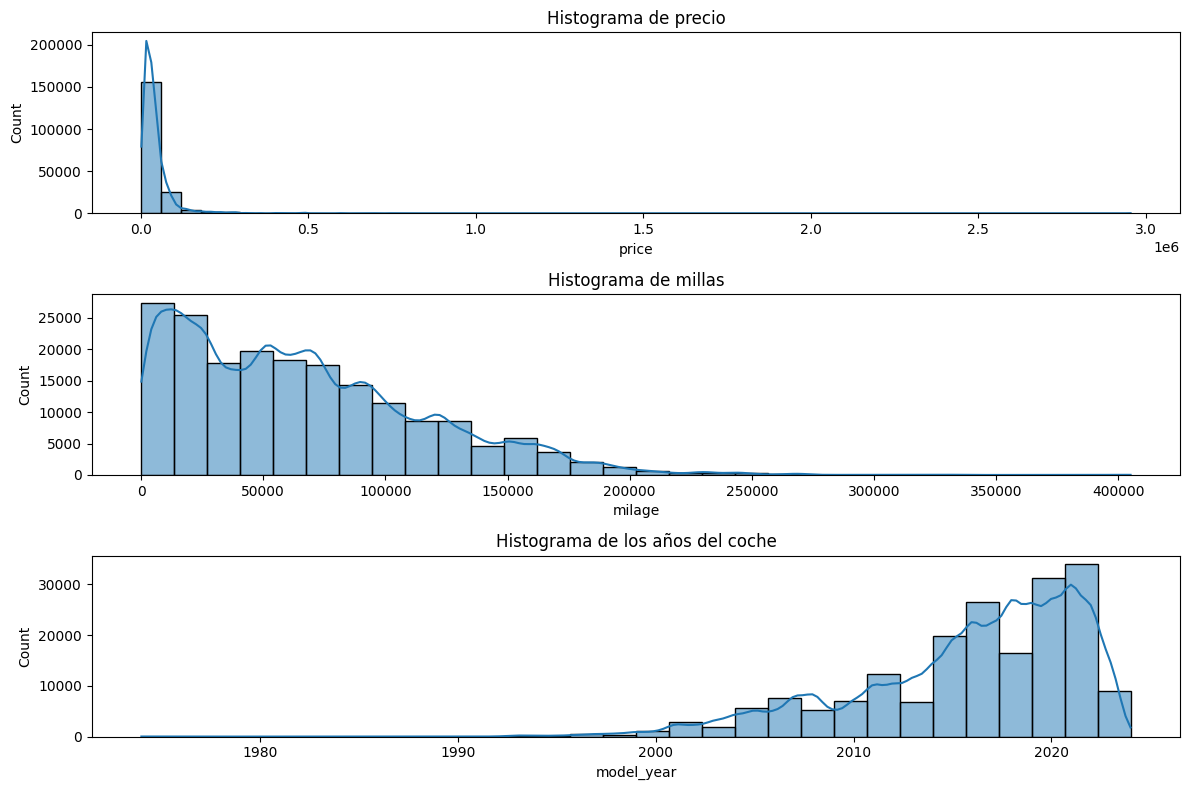

In [143]:
#Histograma
plt.figure(figsize=(12, 8))

#price
plt.subplot(3, 1, 1)
sns.histplot(df_train_copy['price'], bins=50, kde=True)
plt.title('Histograma de precio')

#milage
plt.subplot(3, 1, 2)
sns.histplot(df_train_copy['milage'], bins=30, kde=True)
plt.title('Histograma de millas')

#model_year
plt.subplot(3, 1, 3)
sns.histplot(df_train_copy['model_year'], bins=30, kde=True)
plt.title('Histograma de los años del coche')

plt.tight_layout()
plt.show()



Aquí se observa que las distribuciones no son normales, sino que están hacia la derecha en el caso del año. Lo cual tiene sentido porque a medida que avanzan los años más coches hay y menos coches antiguos.

En el caso de las millas y los precios tiene sentido que tienda a la izquierda ya que es más frecuente que haya coches con menos millas y un precio más bajo, pero que existan excepciones (los outliers que decidimos no eliminar).

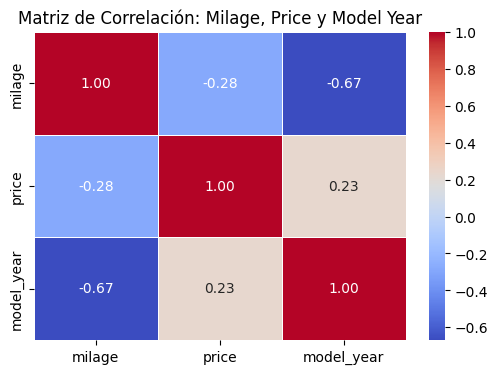

In [144]:
#Matriz de correlación para ver si hay correlaciones entre variables numéricas
corr_df = df_train_copy[['milage', 'price', 'model_year']]
corr_matrix = corr_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Matriz de Correlación: Milage, Price y Model Year")
plt.show()



🔗 Correlación entre precio y millas:
Coeficiente de correlación de Pearson: -0.283
Interpretación: Correlación negativa débil


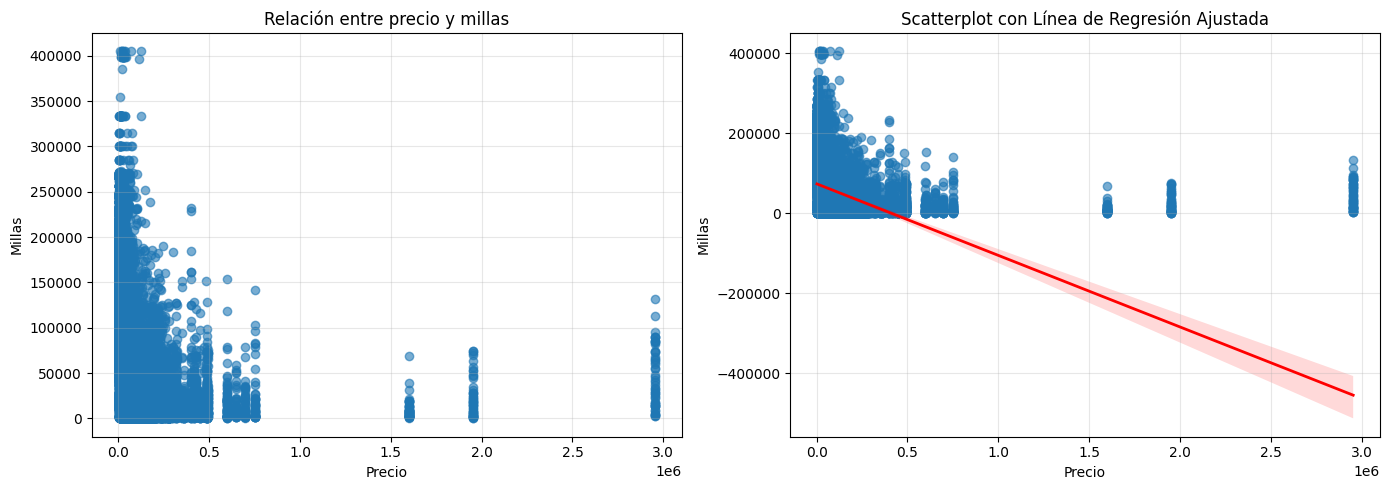

In [145]:
print("\n🔗 Correlación entre precio y millas:")
correlation = df_train_copy['price'].corr(df_train_copy['milage'])
print(f"Coeficiente de correlación de Pearson: {correlation:.3f}")
print("Interpretación: Correlación negativa débil")

# Scatterplot básico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot simple
axes[0].scatter(df_train_copy['price'], df_train_copy['milage'], alpha=0.6)
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Millas')
axes[0].set_title('Relación entre precio y millas')
axes[0].grid(True, alpha=0.3)

# Scatterplot con regresión lineal visual (sólo visual)
sns.regplot(x='price', y='milage', data=df_train_copy, ax=axes[1],
            scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linewidth':2})
axes[1].set_xlabel('Precio')
axes[1].set_ylabel('Millas')
axes[1].set_title('Scatterplot con Línea de Regresión Ajustada')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Aunque tiene sentido pensar que a mayor kilometraje menor precio (correlación negativa fuerte), es normal que tanto en la matriz de correlación como en el diagrama de dispersión den relaciones lineales negativas débiles, ya que los precios pueden variar también según el modelo y la marca. Incluso dentro de una misma marca varía según el modelo, por lo que en principio no daría relación lineal fuerte ni separando por marca, sino por modelos y comparando las millas.


🔗 Correlación entre precio y año:
Coeficiente de correlación de Pearson: 0.232
Interpretación: Correlación positiva débil


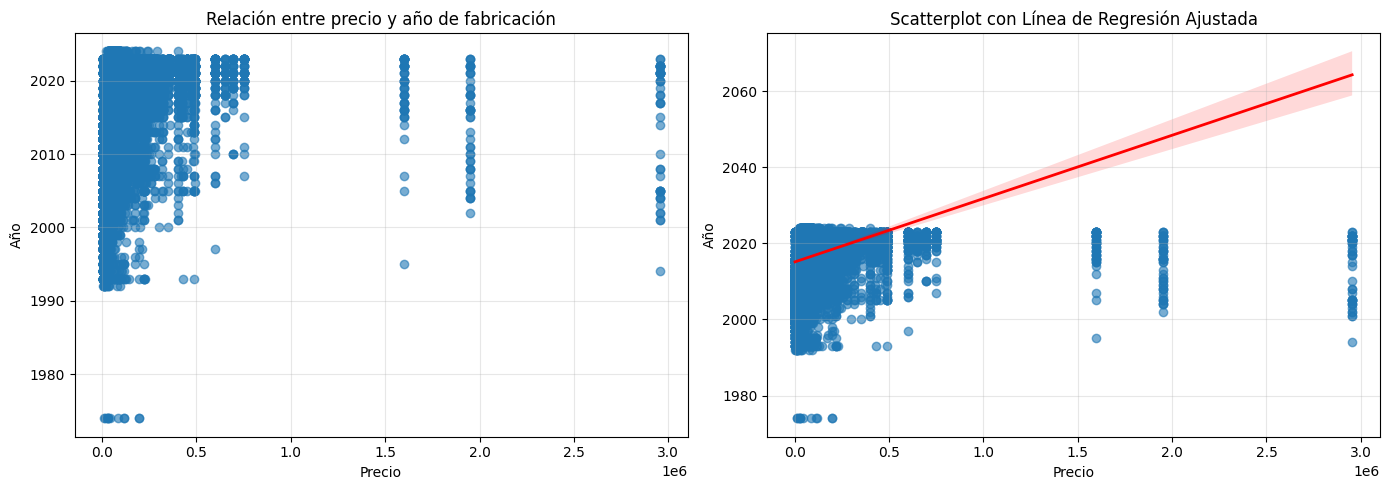

In [146]:
print("\n🔗 Correlación entre precio y año:")
correlation = df_train_copy['price'].corr(df_train_copy['model_year'])
print(f"Coeficiente de correlación de Pearson: {correlation:.3f}")
print("Interpretación: Correlación positiva débil")

# Scatterplot básico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot simple
axes[0].scatter(df_train_copy['price'], df_train_copy['model_year'], alpha=0.6)
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Año')
axes[0].set_title('Relación entre precio y año de fabricación')
axes[0].grid(True, alpha=0.3)

# Scatterplot con regresión lineal visual (sólo visual)
sns.regplot(x='price', y='model_year', data=df_train_copy, ax=axes[1],
            scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linewidth':2})
axes[1].set_xlabel('Precio')
axes[1].set_ylabel('Año')
axes[1].set_title('Scatterplot con Línea de Regresión Ajustada')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparando los precios con el año de fabricación pasaría lo mismo que con las millas, pero en el sentido positivo. Cuanto más reciente, mayor sería el precio. Tampoco se puede encontrar la relación lineal fuerte por lo mismo, el precio depende mucho de la marca y dentro de la marca de los modelos. Un modelo anterior podría valer más que uno más reciente.

# 5. Se guarda el archivo y se exporta.

In [147]:
#Por último, se guarda el archivo y se exporta en formato csv.
from google.colab import files
df_train_copy.to_csv('limpieza_eda_P7_grupo2.csv', index=False)
#Se pondrá un archivo 'limpiezaP7.csv' directamente en la zona de Archivos.

#Por si se quiere descargar automáticamente, quitar # de la siguiente línea
#files.download('limpieza_eda_P7_grupo2.csv')